## Comparison-0-group-wise-protein-groups

> sample-wise

In [1]:
import pandas as pd
import numpy as np
import pyteomics.auxiliary as aux
import seaborn as sns
import matplotlib.pyplot as plt
import os, re, subprocess
from utility_functions import *
DATE, project_palette

('20251015',
 {'canon': 'orangered', 'trembl': 'yellowgreen', 'openprot': 'cornflowerblue'})

In [2]:
# PXDs = [
#     'PXD002057.v0.11.4',
#     'PXD005833.v0.11.4',
#     'PXD014258.v0.11.4',
# ]
# open_or_closed = 'OpenSearch'

# PXDs = [
#     'PXD002057-closed',
#     'PXD005833-closed',
#     'PXD014258-closed',
# ]
# open_or_closed = 'ClosedSearch'

In [3]:
PXDs = [
    'PXD002057-closed',
    'PXD005833-closed',
    'PXD014258-closed',
    'PXD002057.v0.11.4',
    'PXD005833.v0.11.4',
    'PXD014258.v0.11.4',
]
SEARCHES = [
    'canon',
    'trembl',
    'openprot',
]
DATASETS = pd.MultiIndex.from_product([PXDs,SEARCHES])
DATASETS

MultiIndex([( 'PXD002057-closed',    'canon'),
            ( 'PXD002057-closed',   'trembl'),
            ( 'PXD002057-closed', 'openprot'),
            ( 'PXD005833-closed',    'canon'),
            ( 'PXD005833-closed',   'trembl'),
            ( 'PXD005833-closed', 'openprot'),
            ( 'PXD014258-closed',    'canon'),
            ( 'PXD014258-closed',   'trembl'),
            ( 'PXD014258-closed', 'openprot'),
            ('PXD002057.v0.11.4',    'canon'),
            ('PXD002057.v0.11.4',   'trembl'),
            ('PXD002057.v0.11.4', 'openprot'),
            ('PXD005833.v0.11.4',    'canon'),
            ('PXD005833.v0.11.4',   'trembl'),
            ('PXD005833.v0.11.4', 'openprot'),
            ('PXD014258.v0.11.4',    'canon'),
            ('PXD014258.v0.11.4',   'trembl'),
            ('PXD014258.v0.11.4', 'openprot')],
           )

In [4]:
working_folder = "C:/Users/Enrico/OneDrive - UGent/run-ionbot"
# savefig_path = f"publication-data/{DATE}-{open_or_closed}-protgroups.svg"
# savefile_path = f'publication-data/{DATE}-{open_or_closed}-identified-protein-groups-all-datasets.csv.gz'

savefig_path = f"publication-data/{DATE}-protgroups.svg"
savefile_path = f'publication-data/{DATE}-identified-protein-groups-all-datasets.csv.gz'

In [5]:
folders = {search:{dataset_name:[] for dataset_name in PXDs} for search in SEARCHES}
for dataset_name in PXDs:
    for search in SEARCHES:   
        for fld in os.scandir(os.path.join(working_folder, dataset_name, f"{dataset_name}-{search}")):
            if not fld.name.startswith('.') and os.path.isdir(fld.path): 
                folders[search][dataset_name].append(fld)
# folders

In [6]:
# # clear old results to OneDrive avoid conflicts during overwriting
# for dataset_name in PXDs:
#     for search in SEARCHES:  
#         for i,sample_fld in enumerate(folders[search][dataset_name]):
#             print(i,sample_fld.path)
#             for to_delete in ['groups_Occam.tsv','sample_protein_groups_Occam.csv',
#                               'sample-protein-inference-input.pout','subgroups_Occam.tsv']:
#                 try:
#                     os.remove(os.path.join(sample_fld,to_delete))
#                 except:
#                     pass

In [7]:
output_files = []
for dataset_name in PXDs:
    for search in SEARCHES:  
        j = len(folders[search][dataset_name])
        for i,sample_fld in enumerate(folders[search][dataset_name]):
            if os.path.isfile(os.path.join(sample_fld.path,'rank-filtered-results.csv.gz')):
                psms = pd.read_csv(os.path.join(sample_fld.path,'rank-filtered-results.csv.gz'))
            else:
                print(sample_fld.path)
                print('rank filtering results not found')
                continue
            print(dataset_name, f'({1+i}/{j})', sample_fld, psms.shape)
            
            psms.proteins = psms.proteins.apply(lambda x: list(set(x.split(';'))))
            psms = psms[psms.proteins.apply(len)<100] # filter psms with too many interpretations (very rare)
            psms.proteins = psms.apply(lambda row: row.proteins if row.database=='T' else [f'decoy_{_}' for _ in row.proteins], axis=1)
            # psms.proteins
            
            # print(sample_fld.path)
            with open(os.path.join(sample_fld.path, "sample-protein-inference-input.pout"), 'w') as POUT:
                POUT.write('#ionbot_match_id\t#spectrum_title\t#global_q\t#PTMs\t#pep_w_charge\t#proteins\n')
                for _,row in psms[(psms.isCanonical!='Contam')&(psms.proteins.apply(len)<1000)].iterrows():
                    row2 =  [row.ionbot_match_id, row.spectrum_title, f"{row['q-value']:.2e}", 
                             row.modifications, f"{row.charge}.{row.matched_peptide}"]
                    row2 += [f'>xx|{_}|placeholder' if '|' not in _ else _ for _ in row.proteins]
                    row2 =  '\t'.join(row2) + '\n'
                    POUT.write(row2)
            
            pout_file = os.path.join(sample_fld.path, "sample-protein-inference-input.pout")
            groups_file = os.path.join(sample_fld.path, "groups_Occam.tsv")
            subgroups_file = os.path.join(sample_fld.path, "subgroups_Occam.tsv")
            _ = subprocess.run(['pout2prot', 
                                '--fdr_threshold', '1',
                                '--occam', 
                                pout_file, groups_file, subgroups_file])
            print('Run pout2prot =',_.returncode==0)  
            
            psms = psms[['proteins','psm_score']].copy(deep=True)
            psms = psms.explode('proteins')
            psms.sort_values('psm_score', ascending=False, inplace=True)
            psms.drop_duplicates('proteins', inplace=True)
            
            # calculate protein groups scores
            protein_groups = pd.read_csv(groups_file, sep='\t', usecols=['protein accessions'])
            protein_groups.columns = ['proteins']
            protein_groups['psm_score'] = protein_groups.proteins.apply(lambda x: get_max_psm_score(x,psms))
            
            # label decoys
            protein_groups['isDecoy_'] = protein_groups.proteins.apply(group_is_decoy)
            protein_groups['database'] = protein_groups.isDecoy_.apply(lambda x: 'D' if list(x)[-1] else 'T')
            
            protein_groups = protein_groups[['proteins','database','psm_score']].copy(deep=True)
            protein_groups['experiment'] = parse_sample_fld_name(sample_fld.name)[0]
            # protein_groups['exp_number'] =  f'{dataset_name} exp {i+1}' #'-'.join(sample_fld.name.split('-')[:-1])
            protein_groups['PXD'] = dataset_name
            protein_groups['searchDB'] = search
            
            # recalculate q-values
            protein_groups = aux.target_decoy.qvalues(protein_groups, key='psm_score', reverse=True, 
                                                      is_decoy=protein_groups.database=='D',
                                                      q_label='q-value', formula=1, full_output=True)
            out_path = os.path.join(sample_fld.path, "sample_protein_groups_Occam.csv")
            protein_groups.to_csv(out_path, index=False)
            output_files.append(out_path)

PXD002057-closed (1/6) <DirEntry '130327_o2_01_hu_C1_2hr-closed-canon'> (2125, 22)
Run pout2prot = True
PXD002057-closed (2/6) <DirEntry '130327_o2_02_hu_P1_2hr-closed-canon'> (4689, 22)
Run pout2prot = True
PXD002057-closed (3/6) <DirEntry '130327_o2_03_hu_C2_2hr-closed-canon'> (1576, 22)
Run pout2prot = True
PXD002057-closed (4/6) <DirEntry '130327_o2_04_hu_P2_2hr-closed-canon'> (3820, 22)
Run pout2prot = True
PXD002057-closed (5/6) <DirEntry '130327_o2_05_hu_C3_2hr-closed-canon'> (1617, 22)
Run pout2prot = True
PXD002057-closed (6/6) <DirEntry '130327_o2_06_hu_P3_2hr-closed-canon'> (4013, 22)
Run pout2prot = True
PXD002057-closed (1/6) <DirEntry '130327_o2_01_hu_C1_2hr-closed-trembl'> (2033, 22)
Run pout2prot = True
PXD002057-closed (2/6) <DirEntry '130327_o2_02_hu_P1_2hr-closed-trembl'> (4662, 22)
Run pout2prot = True
PXD002057-closed (3/6) <DirEntry '130327_o2_03_hu_C2_2hr-closed-trembl'> (1625, 22)
Run pout2prot = True
PXD002057-closed (4/6) <DirEntry '130327_o2_04_hu_P2_2hr-clos

-----

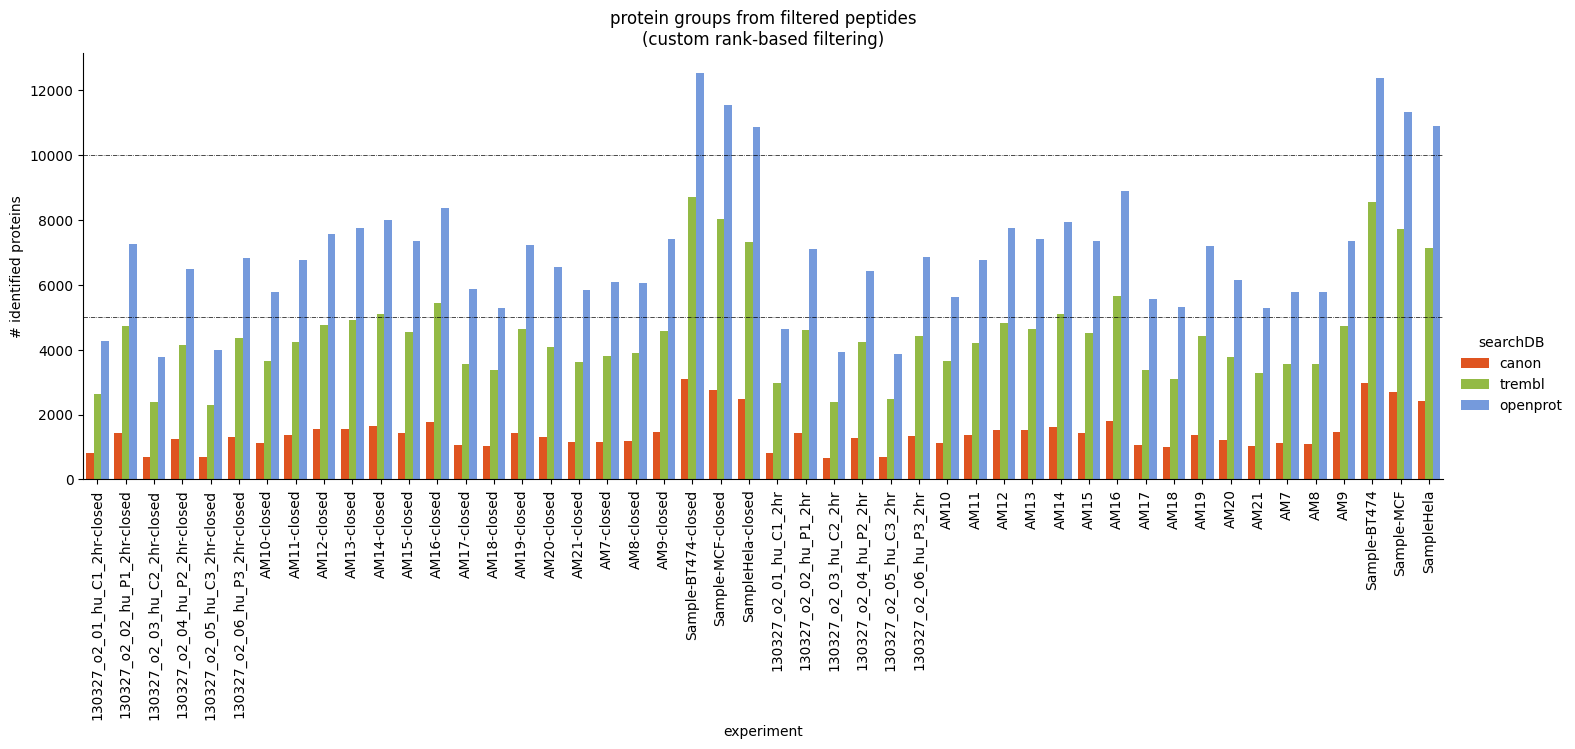

In [8]:
combo = [pd.read_csv(_) for _ in output_files]
combo = pd.concat(combo, ignore_index=True)
combo.rename(columns={'q-value':'global_qvalue','custom_q':'groupwise_qvalue','group_qval':'GroupWalk_q'}, inplace=True)
combo.to_csv(savefile_path, index=False, compression='gzip')

combo.proteins = combo.proteins.str.split(',')
combo = combo.explode('proteins')
combo.drop_duplicates(['proteins','experiment','searchDB'], inplace=True)

sns.catplot(data=combo, kind='count', x='experiment', hue='searchDB', aspect=3, palette=list(project_palette.values()))
plt.xticks(rotation=90)
plt.xlabel('experiment')
plt.ylabel('# identified proteins')
plt.axhline(10000, ls='-.', lw=.5, c='k')
plt.axhline(5000, ls='-.', lw=.5, c='k')
plt.title('protein groups from filtered peptides\n(custom rank-based filtering)')

plt.savefig(savefig_path, dpi=300, bbox_inches='tight')

In [9]:
autosave(
    # extra_labels = '-'+open_or_closed
)

True


----